In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

In [2]:
import sys

sys.path.append('../scripts')

In [3]:
import numpy as np
import scanpy as sc

from utils import set_seed
from train_loo import preprocess_adata
from profiler import profile_training

PROFILER_CSV_PATH = "../results/scaling_stats.csv"

/data/a330d/miniforge3/envs/cellina-base/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [4]:
set_seed(0)

In [5]:
# 221, 232, 242 - simvi

In [6]:
slide_id = 'crc_221' 
dataset_name = slide_id

In [7]:
dataset_path = f'/data2/a330d/datasets/crc/raw_zenodo/{slide_id}.h5ad'
adata = sc.read_h5ad(dataset_path)

In [8]:
adata = preprocess_adata(adata)

/data/a330d/miniforge3/envs/spatial-prop/lib/python3.10/site-packages/scanpy/preprocessing/_simple.py:174: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs["n_counts"] = number
/data/a330d/miniforge3/envs/spatial-prop/lib/python3.10/contextlib.py:142: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  next(self.gen)
Global seed set to 0


In [9]:
MODELS = [
    #'cellina',
    #'cpa', # only run in cpa_cuda env
    #'scgen',
    #'scvi',
    #'scanvi',
    #'scviva',  # always run scanvi before this 
    'simvi',
    #'cellina-graph',
    #'mintflow', # do in separate notebook
]

In [10]:
sizes = [1e3, 1e4, 1e5]
datasets = [adata[np.random.choice(adata.shape[0], int(s), replace=False)].copy() for s in sizes]

In [11]:
from sklearn.model_selection import train_test_split

def get_splits(adata, test_fraction=0.1):
    n_cells = adata.n_obs
    n_holdout = int(n_cells * test_fraction)

    # Randomly choose cells
    test_idx = np.random.choice(n_cells, n_holdout, replace=False)
    all_idx = np.arange(adata.n_obs)
    trainval_idx = np.setdiff1d(all_idx, test_idx)
    validation_size = 0.1
    train_idx, val_idx = train_test_split(
        trainval_idx,
        test_size=validation_size,
        random_state=0,
        shuffle=False
    )
    return train_idx, val_idx, test_idx

In [12]:
from train_loo import DEFAULT_LABELS_KEY, DEFAULT_BATCH_KEY, DEFAULT_DOMAINS_KEY
batch_key = DEFAULT_BATCH_KEY
labels_key = DEFAULT_LABELS_KEY
domains_key = DEFAULT_DOMAINS_KEY

In [13]:
batch_size = 2048
max_epochs = 50

In [ ]:
for dataset in datasets:
    splits = get_splits(dataset)
    for model_name in MODELS:
        print(f"Training {model_name}")
        if model_name == 'cellina':
            from cellina import CellinaModel
            from configs.cellina_config import MODEL_ARGS, TRAIN_ARGS, PLAN_KWARGS
            CellinaModel.setup_anndata(dataset, 
                                    batch_key=batch_key, 
                                    labels_key=labels_key, 
                                    domains_key=domains_key, 
                                    spatial_obsm_key='spatial_x', 
                                    layer='counts')
            model = CellinaModel(dataset, **MODEL_ARGS)

            TRAIN_ARGS['datasplitter_kwargs'] = {
                    "external_indexing": [splits[0], splits[1], splits[2]],
                    }
            TRAIN_ARGS['batch_size'] = batch_size
            TRAIN_ARGS['max_epochs'] = max_epochs
            
            profile_training(
                lambda: model.train(**TRAIN_ARGS, plan_kwargs=PLAN_KWARGS),
                model_name="cellina",
                num_epochs=max_epochs,
                dataset_name=dataset_name,
                dataset_size=dataset.n_obs,
                dataset_path=dataset_path,
                csv_path=PROFILER_CSV_PATH
            )
        
        if model_name == 'cpa':
            import cpa
            from configs.cpa_config import MODEL_ARGS, TRAIN_ARGS, PLAN_KWARGS
            dataset.obs['dose'] = 1.0 # NOTE: dummy dose for compatibility with CPA model
            dataset.obs['data_split'] = 'train'
            dataset.obs.iloc[splits[1], dataset.obs.columns.get_loc('data_split')] = 'valid'
            dataset.obs.iloc[splits[2], dataset.obs.columns.get_loc('data_split')] = 'test'
            cpa.CPA.setup_anndata(dataset,
                    perturbation_key=domains_key,
                    control_group='REF',
                    dosage_key='dose',
                    categorical_covariate_keys=[labels_key],
                    is_count_data=True,
                    max_comb_len=1,
                    )
            model = cpa.CPA(dataset,
                            split_key='data_split',
                            train_split='train',
                            valid_split='valid',
                            test_split='test',
                            **MODEL_ARGS)
            TRAIN_ARGS['batch_size'] = batch_size
            TRAIN_ARGS['max_epochs'] = max_epochs
            
            profile_training(
                lambda: model.train(**TRAIN_ARGS, plan_kwargs=PLAN_KWARGS, save_path='cpa/'),
                model_name="cpa",
                num_epochs=max_epochs,
                dataset_name=dataset_name,
                dataset_size=dataset.n_obs,
                dataset_path=dataset_path,
                csv_path=PROFILER_CSV_PATH
            )

        if model_name == 'cellina_graph':
            from cellina_graph import CellinaModel
            from configs.cellina_graph_config import MODEL_ARGS, TRAIN_ARGS, PLAN_KWARGS
            CellinaModel.setup_anndata(dataset, 
                                    batch_key=batch_key, 
                                    labels_key=labels_key, 
                                    domains_key=domains_key, 
                                    layer='counts',
                                    spatial_connectivities_key='spatial_connectivities', 
                                    )
            model = CellinaModel(dataset, **MODEL_ARGS)
            # Add split info
            TRAIN_ARGS['datasplitter_kwargs'] = {
                    "external_indexing": [splits[0], splits[1], splits[2]],
                    }
            TRAIN_ARGS['batch_size'] = batch_size
            TRAIN_ARGS['max_epochs'] = max_epochs
            
            profile_training(
                lambda: model.train(**TRAIN_ARGS, plan_kwargs=PLAN_KWARGS),
                model_name="cellina-graph",
                num_epochs=max_epochs,
                dataset_name=dataset_name,
                dataset_size=dataset.n_obs,
                dataset_path=dataset_path,
                csv_path=PROFILER_CSV_PATH
            )

        if model_name == 'scgen':
            import pertpy as pt
            from configs.scgen_config import MODEL_ARGS, TRAIN_ARGS, PLAN_KWARGS
            sc.pp.normalize_total(dataset, target_sum=1e4)
            sc.pp.log1p(dataset)
            pt.tl.Scgen.setup_anndata(dataset, batch_key=domains_key, labels_key=labels_key)
            model = pt.tl.Scgen(dataset, **MODEL_ARGS)
            # Add split info
            TRAIN_ARGS['datasplitter_kwargs'] = {
                    "external_indexing": [splits[0], splits[1], splits[2]],
                    }
            TRAIN_ARGS['batch_size'] = batch_size
            TRAIN_ARGS['max_epochs'] = max_epochs
            
            profile_training(
                lambda: model.train(**TRAIN_ARGS, plan_kwargs=PLAN_KWARGS),
                model_name="scgen",
                num_epochs=max_epochs,
                dataset_name=dataset_name,
                dataset_size=dataset.n_obs,
                dataset_path=dataset_path,
                csv_path=PROFILER_CSV_PATH
            )

        if model_name == 'scvi':
            from scvi.model import SCVI
            from configs.cellina_config import TRAIN_ARGS
            SCVI.setup_anndata(dataset, layer="counts", batch_key=batch_key)
            scvi_model = SCVI(dataset, gene_likelihood="nb", 
                              n_layers=2, n_latent=64)
            TRAIN_ARGS['datasplitter_kwargs'] = {
                    "external_indexing": [splits[0], splits[1], splits[2]],
                    }
            TRAIN_ARGS['batch_size'] = batch_size
            TRAIN_ARGS['max_epochs'] = max_epochs
            profile_training(
                lambda: scvi_model.train(**TRAIN_ARGS),
                model_name="scvi",
                num_epochs=max_epochs,
                dataset_name=dataset_name,
                dataset_size=dataset.n_obs,
                dataset_path=dataset_path,
                csv_path=PROFILER_CSV_PATH
            )
        
        if model_name == 'scanvi':
            from scvi.model import SCANVI
            from configs.cellina_config import TRAIN_ARGS
            SCANVI.setup_anndata(
                dataset,
                layer="counts",
                batch_key=batch_key,
                unlabeled_category="ignore",
                labels_key=labels_key,
            )
            scanvi_model = SCANVI(
                adata=dataset,
                n_layers=2,
                n_latent=64,
                linear_classifier=True,
            )
            TRAIN_ARGS['datasplitter_kwargs'] = {
                    "external_indexing": [splits[0], splits[1], splits[2]],
                    }
            TRAIN_ARGS['batch_size'] = batch_size
            TRAIN_ARGS['max_epochs'] = max_epochs
            
            profile_training(
                lambda: scanvi_model.train(**TRAIN_ARGS),
                model_name="scanvi",
                num_epochs=max_epochs,
                dataset_name=dataset_name,
                dataset_size=dataset.n_obs,
                dataset_path=dataset_path,
                csv_path=PROFILER_CSV_PATH
            )

        if model_name == 'scviva':
            import scvi
            from configs.cellina_config import TRAIN_ARGS
            dataset.obsm["SCANVI"] = scanvi_model.get_latent_representation(adata=dataset,
                                                                            batch_size=batch_size)
            setup_kwargs = {
                "sample_key": batch_key,
                "labels_key": labels_key,
                "cell_coordinates_key": "spatial",
                # NOTE: according to their results, SCANVI embs worked better than scvi
                "expression_embedding_key": "SCANVI",
            }
            scvi.external.SCVIVA.preprocessing_anndata(
                dataset,
                k_nn=20,
                **setup_kwargs,
            )
            scvi.external.SCVIVA.setup_anndata(
                dataset,
                layer="counts",
                batch_key=batch_key,
                **setup_kwargs,
            )
            nichevae = scvi.external.SCVIVA(dataset, n_latent=64)
            TRAIN_ARGS['datasplitter_kwargs'] = {
                    "external_indexing": [splits[0], splits[1], splits[2]],
                    }
            TRAIN_ARGS['batch_size'] = batch_size
            TRAIN_ARGS['max_epochs'] = max_epochs
            profile_training(
                lambda: nichevae.train(**TRAIN_ARGS),
                model_name="scviva",
                num_epochs=max_epochs,
                dataset_name=dataset_name,
                dataset_size=dataset.n_obs,
                dataset_path=dataset_path,
                csv_path=PROFILER_CSV_PATH
            )

        if model_name == 'simvi':
            from simvi.model import SimVI
            from pytorch_lightning.utilities.seed import seed_everything
            seed_everything(0)
            
            SimVI.setup_anndata(dataset, batch_key=batch_key)
            n_neighbors = 50
            edge_index = SimVI.extract_edge_index(dataset, 
                                                  n_neighbors=n_neighbors, 
                                                  batch_key=batch_key)
            model = SimVI(dataset,
                          kl_weight=1,
                          kl_gatweight=0.01,
                          lam_mi=1000,
                          permutation_rate=0.5,
                          n_spatial=64,
                          n_intrinsic=64)
            
            profile_training(
                lambda: model.train(edge_index,
                        max_epochs=max_epochs,
                        batch_size=batch_size,
                        use_gpu=True,
                        mae_epochs=max_epochs,
                        device='cuda:0'),
                model_name="simvi",
                num_epochs=max_epochs,
                dataset_name=dataset_name,
                dataset_size=dataset.n_obs,
                dataset_path=dataset_path,
                csv_path=PROFILER_CSV_PATH
            )

# Plotting

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
import matplotlib as mpl
mpl.rcParams["font.family"] = "monospace"

In [6]:
df = pd.read_csv(PROFILER_CSV_PATH)

In [7]:
# for model_name == 'scviva' for a certain dataset_name + dataset_size combination, 
# add the 'scanvi' total train time to the 'scviva' total train time 
# to account for the fact that scanvi is a required preprocessing step for scviva
for dataset_name in df['dataset_name'].unique():
    for dataset_size in df['dataset_size'].unique():
        scanvi_time = df[(df['model_name'] == 'scanvi') & (df['dataset_name'] == dataset_name) & (df['dataset_size'] == dataset_size)]['total_train_time_sec'].sum()
        df.loc[(df['model_name'] == 'scviva') & (df['dataset_name'] == dataset_name) & (df['dataset_size'] == dataset_size), 'total_train_time_sec'] += scanvi_time

In [14]:
palette_dict = {
    'cellina': 'blue',
    'scgen':   'orange',
    'scvi':    'green',
    'scanvi':  'red',
    'cpa':     'purple',
    'scviva':  'brown',
    'simvi':   'grey',
}

In [ ]:
# Base palette (colorblind-friendly)
default_palette = 'colorblind'
base_colors = sns.color_palette(default_palette, n_colors=len(df['model_name'].unique()))

# Convert to dict mapped by model name
palette_dict = dict(zip(df['model_name'].unique(), base_colors))

#palette_dict["cellina-graph"]   = sns.color_palette("Reds", 5)[1:] [2]
palette_dict["cellina"]        = sns.color_palette("Reds", 5)[1:] [3]

# non-spatial green
palette_dict["scgen"]   = sns.color_palette("Greens", 4)[2]
palette_dict["cpa"] = sns.color_palette("Greens", 4)[3]
palette_dict["scvi"] = sns.color_palette("Blues", 4)[1]
palette_dict["scanvi"] = sns.color_palette("Blues", 4)[2]
#palette_dict["scviva"] = sns.color_palette("Blues", 4)[3]
#palette_dict["mintflow"]   = sns.color_palette("Greens", 4)[1]

In [15]:
palette = palette_dict

In [21]:
# Define which models are spatial
spatial_models = ['cellina', 'scviva', 'simvi']
# Non-spatial
non_spatial_models = ['scgen', 'scvi', 'scanvi', 'cpa']

In [25]:
dataset_name = "crc_221"
df_sub = df[df['dataset_name'] == dataset_name]

In [26]:
df_sub = df_sub.groupby(['model_name', 'dataset_size'], as_index=False)['total_train_time_sec'].mean()
# Add a column to df_sub indicating line style
df_sub['type'] = df_sub['model_name'].apply(
    lambda x: 'spatial' if x in spatial_models else 'non-spatial'
)

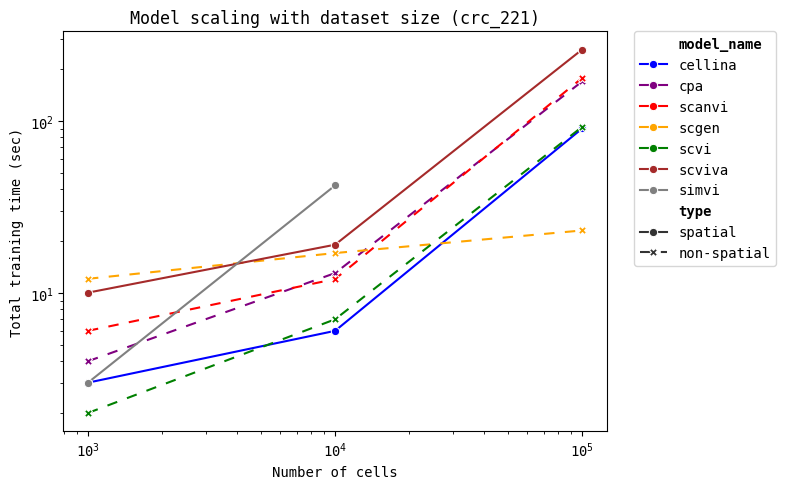

In [27]:
plt.figure(figsize=(8,5))
sns.lineplot(
    data=df_sub,
    x='dataset_size',
    y='total_train_time_sec',
    hue='model_name',
    marker='o',
    palette=palette,
    style='type',       # use this column for solid/dashed
    markers=True,
    dashes={'spatial': '', 'non-spatial': (5,5)},  # optional: specify dash pattern
)
plt.xscale('log')
plt.yscale('log')
plt.xlabel('Number of cells')
plt.ylabel('Total training time (sec)')
plt.title(f'Model scaling with dataset size ({dataset_name})')

leg = plt.legend(
    bbox_to_anchor=(1.05, 1),  # x=1.05 moves it slightly outside to the right
    loc='upper left',
    borderaxespad=0,
)

# Bold only category headings
category_headings = ['model_name', 'type']  # adjust to your legend category names
for text in leg.get_texts():
    if text.get_text() in category_headings:
        text.set_fontweight('bold')

plt.tight_layout()
plt.savefig(f'../figures/model_scaling_{dataset_name}.svg', format='svg', bbox_inches="tight")
plt.show()

In [28]:
df_avg = df.groupby(['model_name', 'dataset_size'], as_index=False)['total_train_time_sec'].mean()
# Add a column to df_avg indicating line style
df_avg['type'] = df_avg['model_name'].apply(
    lambda x: 'spatial' if x in spatial_models else 'non-spatial'
)

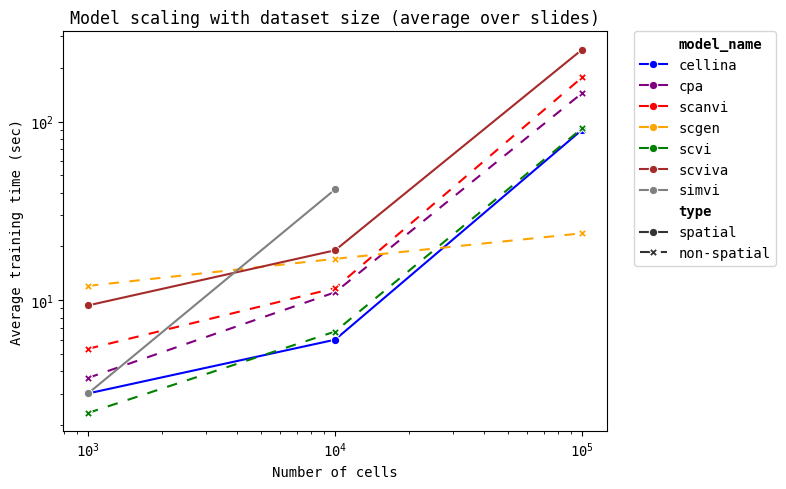

In [29]:
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=df_avg,
    x='dataset_size',
    y='total_train_time_sec',
    hue='model_name',
    marker='o',
    palette=palette,
    style='type',       # use this column for solid/dashed
    markers=True,
    dashes={'spatial': '', 'non-spatial': (5,5)},  # optional: specify dash pattern
    #legend='full'
)
plt.xscale('log')  # optional: for wide range of dataset sizes
plt.yscale('log')  # optional: for wide range of times
plt.xlabel('Number of cells')
plt.ylabel('Average training time (sec)')
plt.title(f'Model scaling with dataset size (average over slides)')

leg = plt.legend(
    bbox_to_anchor=(1.05, 1),  # x=1.05 moves it slightly outside to the right
    loc='upper left',
    borderaxespad=0,
)

# Bold only category headings
category_headings = ['model_name', 'type']  # adjust to your legend category names
for text in leg.get_texts():
    if text.get_text() in category_headings:
        text.set_fontweight('bold')
        
plt.tight_layout()
plt.savefig(f'../figures/model_scaling_average.svg', format='svg', bbox_inches="tight")
plt.show()